## Cellpose-SAM: superhuman generalization for cellular segmentation

Marius Pachitariu, Michael Rariden, Carsen Stringer

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

This notebook shows how to process your own 2D or 3D images, saved on Google Drive.

This notebook is adapted from the notebook by Pradeep Rajasekhar, inspired by the [ZeroCostDL4Mic notebook series](https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki).

### Make sure you have GPU access enabled by going to Runtime -> Change Runtime Type -> Hardware accelerator and selecting GPU

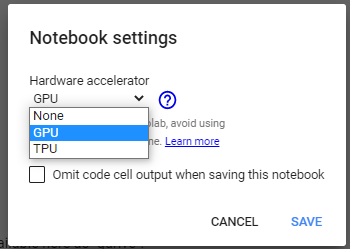

### Mount your google drive

Run this cell to connect your Google Drive to colab:
* Click on the URL.
* Sign in your Google Account.

You will either have to:
* copy the authorisation code and enter it into box below OR
* in the new google colab, you can just click "Allow" and it should connect.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



Then click on "Folder" icon on the Left, press the refresh button. Your Google Drive folder should now be available here as "gdrive".


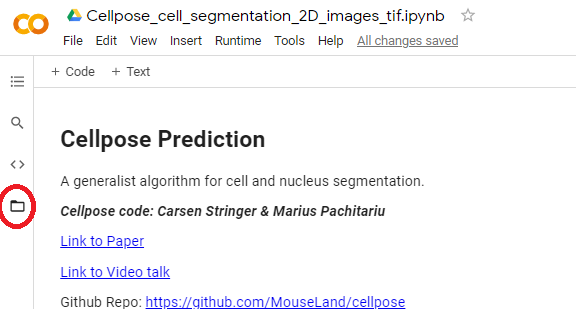

Click on the triangle icon and it will allow you to access whole drive. Navigate to the folder containing your images. Once you are there, click on the three dots on the right of the folder and select "Copy Path"

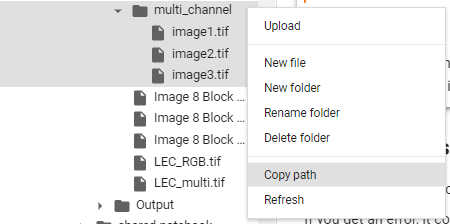

Copy and paste this path in the **dir** string below

### Install Cellpose-SAM


In [ ]:
!pip install git+https://www.github.com/mouseland/cellpose.git

  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-zrvgr4su
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-zrvgr4su
  Resolved https://www.github.com/mouseland/cellpose.git to commit 6d23968d924fc3b8e419a2d79349888f4b07aa29
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 69.0 MB/s eta 0:00:00
  Created wheel for cellpose: filename=cellpose-4.0.9.dev5+g6d23968d9-py3-none-any.whl size=212314 sha256=a6a9f2a0a9148da2ab3d85163842cbfad451172a0a1db833271eeabf44917def
  Stored in directory: /tmp/pip-ephem-wheel-cache-oqg9uh3_/wheels/df/b6/31/a3013c44290eabb46f4c06d1efb19744124fcad2d59684ec5e
Successfully built cellpose


Check GPU and instantiate model - will download weights.

In [ ]:
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted
import requests # Import requests for downloading files

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

# Define persistent model directory in Google Drive
MODEL_DIR = Path("/content/drive/MyDrive/cellpose_models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Define the specific model file path
MODEL_NAME = "cpsam" # Cellpose-SAM model name
MODEL_FILE_PATH = MODEL_DIR / MODEL_NAME

# Check if the model file exists in Google Drive, if not, download it
if not MODEL_FILE_PATH.exists():
  print(f"Downloading {MODEL_NAME} model to {MODEL_FILE_PATH}...")
  # URL to the Cellpose-SAM model from Hugging Face, as observed in previous logs
  MODEL_URL = f"https://huggingface.co/mouseland/cellpose-sam/resolve/main/{MODEL_NAME}"
  response = requests.get(MODEL_URL, stream=True)
  response.raise_for_status() # Raise an exception for HTTP errors
  with open(MODEL_FILE_PATH, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
      f.write(chunk)
  print("Download complete.")
else:
  print(f"{MODEL_NAME} model already exists at {MODEL_FILE_PATH}.")

# Instantiate the model, loading weights from the persistent path
# Use 'None' for model_type when providing a pretrained_model path directly
model = models.CellposeModel(gpu=True, model_type=None, pretrained_model=str(MODEL_FILE_PATH))

2026-02-06 02:23:26,930 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-02-06 02:23:26,931 [INFO] 
cellpose version: 	4.0.9.dev5+g6d23968d9 
platform:       	linux 
python version: 	3.12.12 
torch version:  	2.9.0+cu126
2026-02-06 02:23:26,932 [INFO] ** TORCH CUDA version installed and working. **
Download complete.
2026-02-06 02:23:40,985 [INFO] ** TORCH CUDA version installed and working. **
2026-02-06 02:23:40,985 [INFO] >>>> using GPU (CUDA)
2026-02-06 02:23:43,406 [INFO] >>>> loading model /content/drive/MyDrive/cellpose_models/cpsam


Input directory with your images:

In [ ]:
# *** change to your google drive folder path ***
dir = "/content/drive/MyDrive/Colab_Notebooks/CellposeSAM_LB/Image_Sequence"
dir = Path(dir)
if not dir.exists():
  raise FileNotFoundError("directory does not exist")

# *** change to your image extension ***
image_ext = ".tif"

# list all files
files = natsorted([f for f in dir.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name])

if(len(files)==0):
  raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
else:
  print(f"{len(files)} images in folder:")

for f in files:
  print(f.name)

128 images in folder:
20241017-MsLB-nT-dt7.5-z20-6-z3-maximum-projection-XY over Z-adj-rot-10000.tif
20241017-MsLB-nT-dt7.5-z20-6-z3-maximum-projection-XY over Z-adj-rot-10001.tif
20241017-MsLB-nT-dt7.5-z20-6-z3-maximum-projection-XY over Z-adj-rot-10002.tif
20241017-MsLB-nT-dt7.5-z20-6-z3-maximum-projection-XY over Z-adj-rot-10003.tif
20241017-MsLB-nT-dt7.5-z20-6-z3-maximum-projection-XY over Z-adj-rot-10004.tif
20241017-MsLB-nT-dt7.5-z20-6-z3-maximum-projection-XY over Z-adj-rot-10005.tif
20241017-MsLB-nT-dt7.5-z20-6-z3-maximum-projection-XY over Z-adj-rot-10006.tif
20241017-MsLB-nT-dt7.5-z20-6-z3-maximum-projection-XY over Z-adj-rot-10007.tif
20241017-MsLB-nT-dt7.5-z20-6-z3-maximum-projection-XY over Z-adj-rot-10008.tif
20241017-MsLB-nT-dt7.5-z20-6-z3-maximum-projection-XY over Z-adj-rot-10009.tif
20241017-MsLB-nT-dt7.5-z20-6-z3-maximum-projection-XY over Z-adj-rot-10010.tif
20241017-MsLB-nT-dt7.5-z20-6-z3-maximum-projection-XY over Z-adj-rot-10011.tif
20241017-MsLB-nT-dt7.5-z20-6-z

## Run Cellpose-SAM on one image in folder

Here are some of the parameters you can change:

* ***flow_threshold*** is  the  maximum  allowed  error  of  the  flows  for  each  mask.   The  default  is 0.4.
    *  **Increase** this threshold if cellpose is not returning as many masks as you’d expect (or turn off completely with 0.0)
    *   **Decrease** this threshold if cellpose is returning too many ill-shaped masks.

* ***cellprob_threshold*** determines proability that a detected object is a cell.   The  default  is 0.0.
    *   **Decrease** this threshold if cellpose is not returning as many masks as you’d expect or if masks are too small
    *   **Increase** this threshold if cellpose is returning too many masks esp from dull/dim areas.

* ***tile_norm_blocksize*** determines the size of blocks used for normalizing the image. The default is 0, which means the entire image is normalized together.
  You may want to change this to 100-200 pixels if you have very inhomogeneous brightness across your image.



In [ ]:
img = io.imread(files[0])
print(img.shape[1])
print(f'your image has shape: {img.shape}. Assuming channel dimension is last with {img.shape[-1]} channels')

1122
your image has shape: (710, 1122). Assuming channel dimension is last with 1122 channels


### Channel Selection:

- Use the dropdowns below to select the _zero-indexed_ channels of your image to segment. The order does not matter. Remember to rerun the cell after you edit the dropdowns.

- If you have a histological image taken in brightfield, you don't need to adjust the channels.

- If you have a fluroescent image with multiple stains, you should choose one channel with a cytoplasm/membrane stain, one channel with a nuclear stain, and set the third channel to `None`. Choosing multiple channels may produce segmentaiton of all the structures in the image. If you have retrained the model on your data with a thrid stain (described below), you can run segmentation with all channels.

In [ ]:
first_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]
second_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]
third_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]

In [ ]:
# Define image_type based on the loaded img
if img.ndim == 3 and img.shape[-1] > 5: # Heuristic: if last dim is large, assume (Z, H, W)
    image_type = '3D_Z_STACK'
elif img.ndim == 3 and img.shape[-1] <= 5: # Assume (Height, Width, Channels)
    image_type = '2D_MULTICHANNEL'
elif img.ndim == 2:
    image_type = '2D_SINGLE_CHANNEL'
else:
    image_type = 'UNKNOWN'

print(f"Detected image_type: {image_type}")

Detected image_type: 2D_SINGLE_CHANNEL


Image recognized as single-channel (2D or 3D Z-stack). Channel selection is not applicable.
2026-02-06 03:01:22,224 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-02-06 03:01:22,228 [INFO] processing image with (710, 1122) HW, and 3 channels


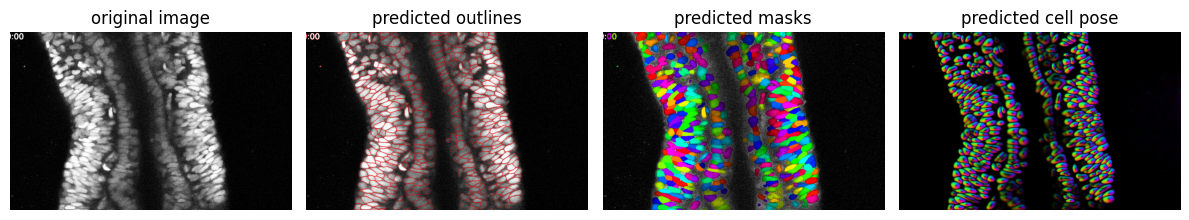

In [ ]:
selected_channels = []
channels_for_eval = [None, None] # Default for grayscale/single-channel for Cellpose-SAM

if image_type == '2D_MULTICHANNEL':
    for i, c in enumerate([first_channel, second_channel, third_channel]):
        if c == 'None':
            continue
        if int(c) >= img.shape[-1]: # Use >= as channel index should be less than total channels
            assert False, 'invalid channel index, must be less than the number of channels in your image'
        selected_channels.append(int(c))

    if len(selected_channels) == 0:
        # If no channels are selected for a multichannel image, use all channels for eval (if C <= 3) or the first channel for plotting
        if img.shape[-1] <= 3:
            img_to_eval = img
            img_to_plot = img
            # For 2D multichannel, Cellpose expects (H, W, C), so no explicit channels arg if <=3 channels
        else:
            img_to_eval = img[:, :, 0]
            img_to_plot = img[:, :, 0]
            channels_for_eval = [0,0] # If only using first channel
        print("No channels selected for 2D multichannel image. Using all available channels (up to 3) for evaluation and the first channel for plotting.")
    else:
        # Create an image with only the selected channels, up to 3 channels for display compatibility
        img_to_eval = np.zeros((*img.shape[:-1], len(selected_channels)), dtype=img.dtype)
        for i, c_idx in enumerate(selected_channels):
            img_to_eval[:, :, i] = img[:, :, c_idx]
        img_to_plot = img_to_eval
        # If specific channels are selected, channels_for_eval needs to reflect this for model.eval
        # Assuming selected_channels are mapped to cytoplasm/nucleus
        channels_for_eval = [selected_channels[0], selected_channels[1]] if len(selected_channels) >= 2 else [selected_channels[0], None]

elif image_type == '3D_Z_STACK' or image_type == '2D_SINGLE_CHANNEL':
    # For single-channel images, ensure explicit channel dimension for Cellpose if needed
    if img.ndim == 3: # 3D_Z_STACK
        img_to_eval = np.expand_dims(img, axis=-1) # Add a channel dimension: (Z, H, W, 1)
    elif img.ndim == 2: # 2D_SINGLE_CHANNEL
        img_to_eval = np.expand_dims(img, axis=-1) # Add a channel dimension: (H, W, 1)
    else:
        img_to_eval = img # Should not happen with previous checks
    img_to_plot = img # Keep original for slicing/plotting
    channels_for_eval = [None, None] # Explicitly indicate grayscale for Cellpose-SAM
    print("Image recognized as single-channel (2D or 3D Z-stack). Channel selection is not applicable.")

# Parameters below can be changed to optimize segmentation quality
flow_threshold = 0.9
cellprob_threshold = -2.0
tile_norm_blocksize = 0

# Run model evaluation, explicitly passing channels_for_eval
masks, flows, styles = model.eval(img_to_eval, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize}, channels=channels_for_eval)

# Prepare image and masks for 2D plotting
if image_type == '3D_Z_STACK':
    # Plot the middle slice of the 3D image and masks
    z_slice = img.shape[0] // 2
    img_display = img_to_plot[z_slice] # img_to_plot is original (Z,H,W)
    masks_display = masks[z_slice] # masks should now be (Z,H,W)
    flows_display = flows[0][z_slice] # Slice flows[0] as well
    print(f"Plotting middle Z-slice ({z_slice}) for 3D image.")
elif image_type == '2D_MULTICHANNEL' and len(selected_channels) == 1:
    # Squeeze the channel dimension for 1-channel image for plotting
    img_display = img_to_plot.squeeze() # (H,W,1) -> (H,W)
    masks_display = masks.squeeze() if masks.ndim > 2 else masks # (H,W,1) -> (H,W) if mask was 3D
    flows_display = flows[0] # For 2D, flows[0] is already 2D (H,W) or 3D (H,W,C)
elif image_type == '2D_SINGLE_CHANNEL' or (image_type == '2D_MULTICHANNEL' and img_to_plot.ndim == 2):
    img_display = img_to_plot
    masks_display = masks
    flows_display = flows[0] # For 2D, flows[0] is already 2D (H,W) or 3D (H,W,C)
else: # For 2D_MULTICHANNEL with >1 selected channels, or other cases that are already 2D or (H,W,C_3or4)
    img_display = img_to_plot
    masks_display = masks
    flows_display = flows[0] # For 2D, flows[0] is already 2D (H,W) or 3D (H,W,C)


fig = plt.figure(figsize=(12,5))
# Ensure img_display and masks_display are 2D or 3D (H,W,C_3or4) for plot.show_segmentation
# The current logic should result in 2D img_display and masks_display for the plotted slice
plot.show_segmentation(fig, img_display, masks_display, flows_display)
plt.tight_layout()
plt.show()

## Run Cellpose-SAM on folder of images

if you have many large images, you may want to run them as a loop over images



In [ ]:
masks_ext = ".png" if image_ext == ".png" else ".tif"
for i in trange(len(files)):
    f = files[i]
    img = io.imread(f)

    # Determine image_type for the current image in the loop
    current_image_type = 'UNKNOWN'
    if img.ndim == 3 and img.shape[-1] > 5:
        current_image_type = '3D_Z_STACK'
    elif img.ndim == 3 and img.shape[-1] <= 5:
        current_image_type = '2D_MULTICHANNEL'
    elif img.ndim == 2:
        current_image_type = '2D_SINGLE_CHANNEL'

    img_to_eval = img
    if current_image_type == '2D_MULTICHANNEL':
        if len(selected_channels) == 0:
            # If no channels are selected for a multichannel image, use all channels for eval (if C <= 3)
            if img.shape[-1] <= 3:
                img_to_eval = img
            else:
                img_to_eval = img[:, :, 0] # Default to first channel if too many for eval
        else:
            # Create an image with only the selected channels for evaluation
            img_to_eval = np.zeros((*img.shape[:-1], len(selected_channels)), dtype=img.dtype)
            for j, c_idx in enumerate(selected_channels):
                img_to_eval[:, :, j] = img[:, :, c_idx]
    # For 3D_Z_STACK or 2D_SINGLE_CHANNEL, img_to_eval is already img

    masks, flows, styles = model.eval(img_to_eval, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks)

  0%|          | 0/128 [00:00<?, ?it/s]

2026-02-06 03:02:44,113 [INFO] processing grayscale image with (710, 1122) HW


  1%|          | 1/128 [00:08<19:01,  8.99s/it]

2026-02-06 03:02:53,965 [INFO] processing grayscale image with (710, 1122) HW


  2%|▏         | 2/128 [00:19<20:15,  9.65s/it]

...

 98%|█████████▊| 126/128 [19:24<00:18,  9.23s/it]

2026-02-06 03:22:08,347 [INFO] processing grayscale image with (710, 1122) HW


 99%|█████████▉| 127/128 [19:33<00:09,  9.20s/it]

2026-02-06 03:22:17,472 [INFO] processing grayscale image with (710, 1122) HW


100%|██████████| 128/128 [19:42<00:00,  9.24s/it]


if you have small images, you may want to load all of them first and then run, so that they can be batched together on the GPU

In [ ]:
print("loading images")
imgs = [io.imread(files[i]) for i in trange(len(files))]

print("running cellpose-SAM")
masks, flows, styles = model.eval(imgs, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

print("saving masks")
for i in trange(len(files)):
    f = files[i]
    io.imsave(dir / (f.stem + "_masks" + masks_ext), masks[i])

loading images


  0%|          | 0/1 [00:00<?, ?it/s]

2026-01-02 06:07:35,506 [INFO] reading tiff with 11 planes



100%|██████████| 1/1 [00:00<00:00, 36.28it/s]

running cellpose-SAM
2026-01-02 06:07:35,529 [WARNING] Found more than 3 channels, only using first 3
2026-01-02 06:07:35,536 [INFO] processing image with (887, 937) HW, and 3 channels


AttributeError: 'list' object has no attribute 'shape'

to save your masks for ImageJ, run the following code:

In [ ]:
for i in trange(len(files)):
    f = files[i]
    # `masks` is a list of mask arrays from the previous model.eval call
    # We need to pass masks[i] to io.imsave
    io.imsave(dir / (f.name + "_masks" + masks_ext), masks[i])
    # io.save_rois also expects the mask array as the first argument
    io.save_rois(masks[i], f)

100%|██████████| 1/1 [00:00<00:00,  1.91it/s]


In [ ]:
# *** change to your google drive folder path ***
dir = "/content/drive/MyDrive/20260101"
dir = Path(dir)
if not dir.exists():
  raise FileNotFoundError("directory does not exist")

# *** change to your image extension ***
image_ext = ".tif"

# list all files
files = natsorted([f for f in dir.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name])

if(len(files)==0):
  raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
else:
  print(f"{len(files)} images in folder:")

for f in files:
  print(f.name)

1 images in folder:
DUP_20241106-LBex-nT-Fgf10left-dt5-maximum-projection-XY over Z-z3.ome-1-rot-60.tif


In [ ]:
img_3D = io.imread(files[0])

2026-01-02 06:11:34,310 [INFO] reading tiff with 11 planes


100%|██████████| 11/11 [00:00<00:00, 729.67it/s]


In [ ]:
# 2. computes masks in 2D slices and stitches masks in 3D based on mask overlap
print('running cellpose 2D + stitching masks')
masks, flows, _ = model.eval(img_3D, z_axis=0, channel_axis=[None, None],
                                                  batch_size=32,
                                                  do_3D=False, stitch_threshold>0)

SyntaxError: positional argument follows keyword argument (ipython-input-2442137274.py, line 5)

Plotting middle Z-slice (5) for 3D image.


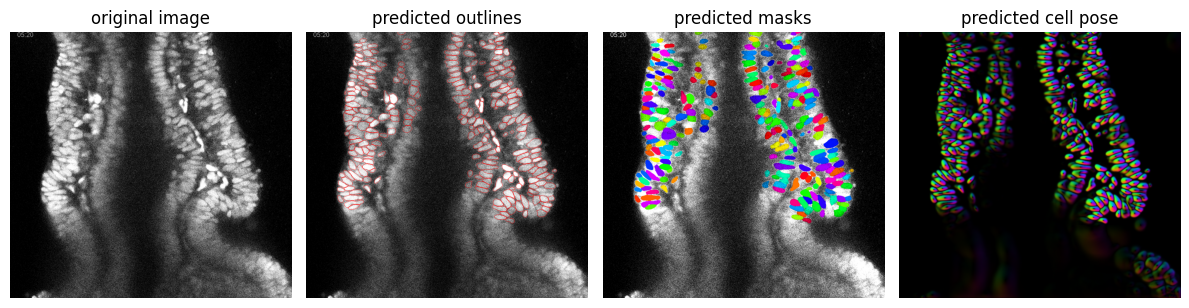

In [ ]:
# Prepare image and masks for 2D plotting
if image_type == '3D_Z_STACK':
    # Plot the middle slice of the 3D image and masks
    z_slice = img_to_plot.shape[0] // 2 # Corrected: use img_to_plot.shape[0]
    img_display = img_to_plot[z_slice] # img_to_plot is original (Z,H,W)
    masks_display = masks[z_slice] # masks should now be (Z,H,W)
    flows_display = flows[0][z_slice] # Slice flows[0] as well
    print(f"Plotting middle Z-slice ({z_slice}) for 3D image.")
elif image_type == '2D_MULTICHANNEL' and len(selected_channels) == 1:
    # Squeeze the channel dimension for 1-channel image for plotting
    img_display = img_to_plot.squeeze() # (H,W,1) -> (H,W)
    masks_display = masks.squeeze() if masks.ndim > 2 else masks # (H,W,1) -> (H,W) if mask was 3D
    flows_display = flows[0] # For 2D, flows[0] is already 2D (H,W) or 3D (H,W,C)
elif image_type == '2D_SINGLE_CHANNEL' or (image_type == '2D_MULTICHANNEL' and img_to_plot.ndim == 2):
    img_display = img_to_plot
    masks_display = masks
    flows_display = flows[0] # For 2D, flows[0] is already 2D (H,W) or 3D (H,W,C)
else: # For 2D_MULTICHANNEL with >1 selected channels, or other cases that are already 2D or (H,W,C_3or4)
    img_display = img_to_plot
    masks_display = masks
    flows_display = flows[0] # For 2D, flows[0] is already 2D (H,W) or 3D (H,W,C)


fig = plt.figure(figsize=(12,5))
# Ensure img_display and masks_display are 2D or 3D (H,W,C_3or4) for plot.show_segmentation
# The current logic should result in 2D img_display and masks_display for the plotted slice
plot.show_segmentation(fig, img_display, masks_display, flows_display)
plt.tight_layout()
plt.show()

ValueError: num must be an integer with 1 <= num <= 7, not 8

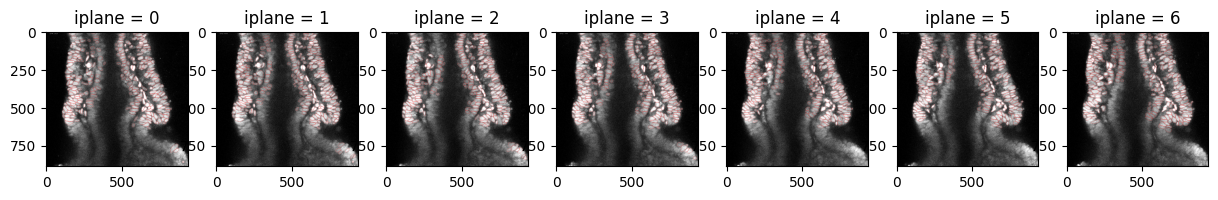

In [ ]:
from cellpose import utils, io

# DISPLAY RESULTS 3D flows => masks
plt.figure(figsize=(15,3))
# Adjust the range to only iterate over available Z-slices in img_3D
# Using img_3D.shape[0] as the stop for np.arange ensures we don't go out of bounds.
# The step of 10 might mean not all slices are plotted for smaller stacks,
# but it fixes the IndexError.
for i,iplane in enumerate(np.arange(0, img_3D.shape[0], 1, int)):
  # Corrected: Select the entire iplane-th Z-slice (2D grayscale image)
  img0 = plot.image_to_rgb(img_3D[iplane].copy())
  plt.subplot(1,11,i+1)
  outlines = utils.masks_to_outlines(masks[iplane])
  outX, outY = np.nonzero(outlines)
  imgout= img0.copy()
  # Ensure imgout has enough dimensions for indexing with outX, outY
  # img0 should already be (H, W, 3) from image_to_rgb, so this is safe
  imgout[outX, outY] = np.array([255,75,75])
  plt.imshow(imgout)
  plt.title('iplane = %d'%iplane)

In [ ]:
io.imsave(dir / (f.stem + "_masks" + masks_ext), masks)